# EDA

In [6]:
from sber.datasets import retrieve_all_datasets, SberDatasetsConfig, unpack_all_datasets
from common.logger import JUPYTER_LOGGER as logger

In [9]:
data = retrieve_all_datasets(SberDatasetsConfig())
data = unpack_all_datasets(data)
logger.info(f"Размеры датасетов: {len(data[0])}")

2026-03-28 16:54:07,596 - sber-datasets - INFO - [SBER-DATASETS 📦] Загружаю датасет: rubq-20
2026-03-28 16:54:07,601 - sber-datasets - INFO - [SBER-DATASETS 📦] Найден локальный файл датасета: C:\Users\User\Desktop\dirs\Dev\hack-mfti\sber\data\gitignore\rubq-20\RuBQ_2.0_dev.json
2026-03-28 16:54:08,152 - sber-datasets - INFO - [SBER-DATASETS 📦] Загружаю датасет: tape-chegeka.raw
2026-03-28 16:54:12,457 - sber-datasets - INFO - [SBER-DATASETS 📦] Загружаю датасет: tape-multiq.raw
2026-03-28 16:54:16,971 - jupyter-notebooks - INFO - [JUPYTER 📓] Размеры датасетов: 31012


In [8]:
queries, answers = data
logger.info(f"Пример запроса: {queries[0]}")
logger.info(f"Пример ответа: {answers[0]}")

2026-03-28 16:54:03,570 - jupyter-notebooks - INFO - [JUPYTER 📓] Пример запроса: Какой стране принадлежит знаменитый остров Пасхи?
2026-03-28 16:54:03,581 - jupyter-notebooks - INFO - [JUPYTER 📓] Пример ответа: Чили


In [23]:
import nltk

nltk.download("stopwords")
stop_words = set(nltk.corpus.stopwords.words("russian"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


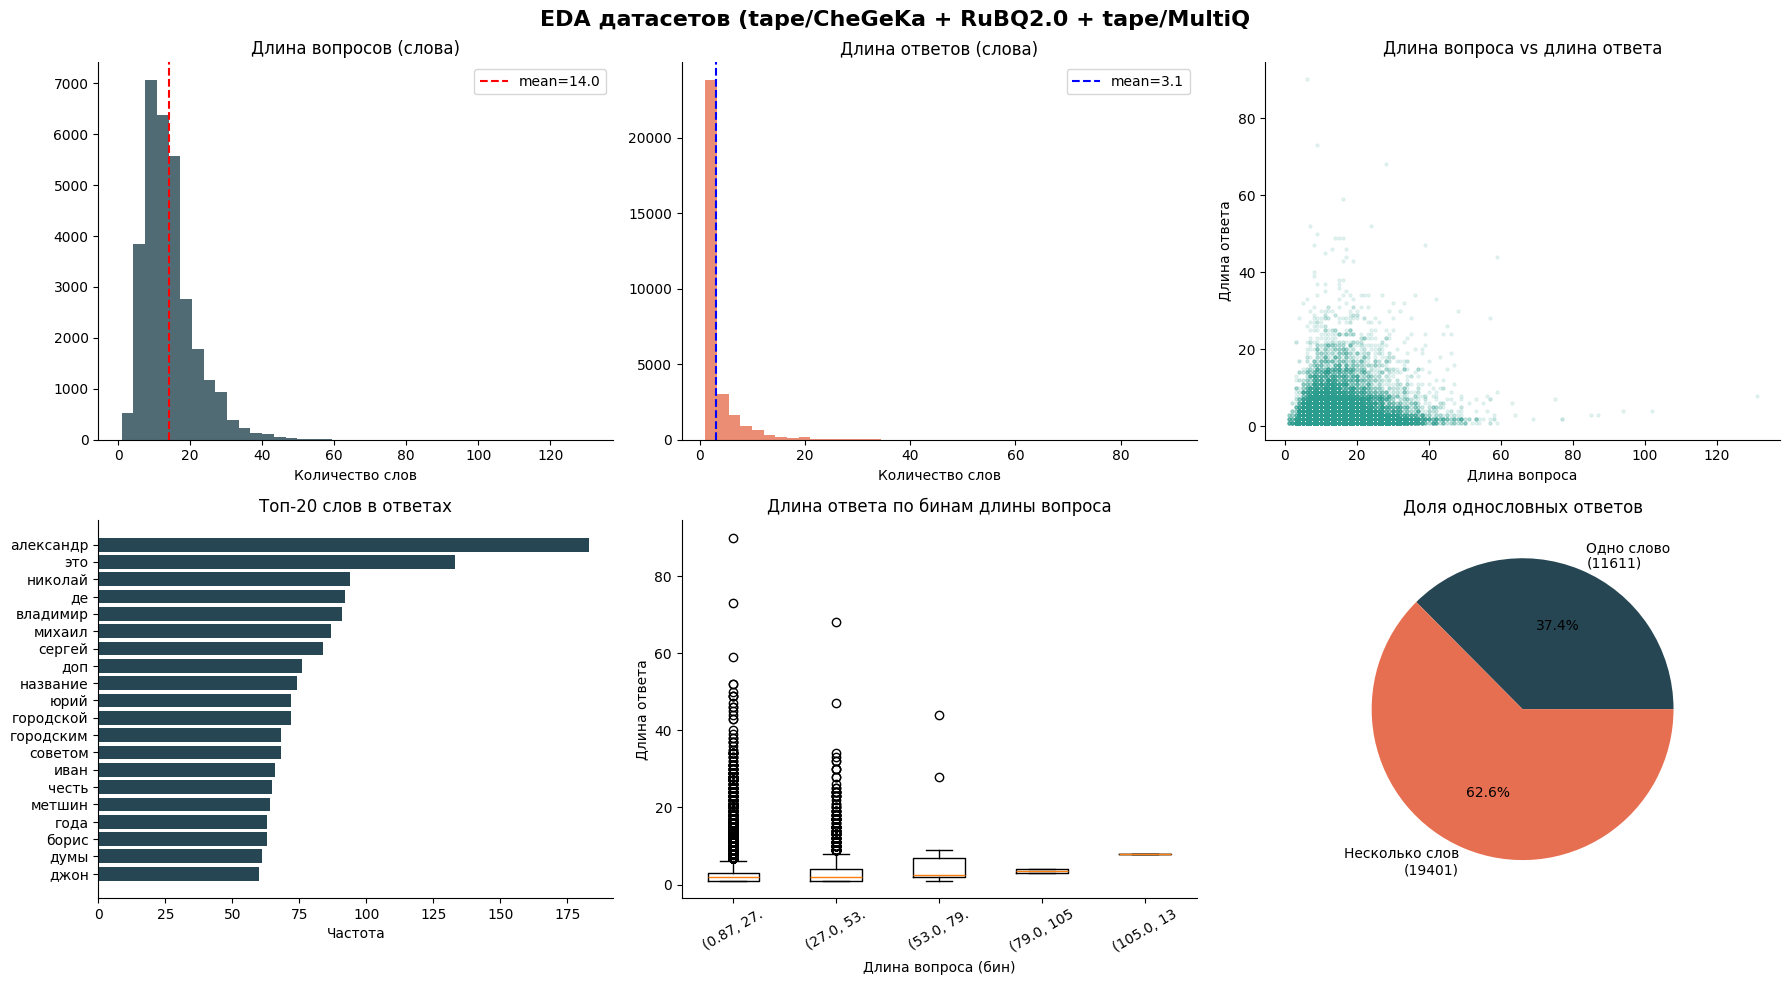

2026-03-28 17:15:03,057 - jupyter-notebooks - INFO - [JUPYTER 📓] Всего примеров: 31012
2026-03-28 17:15:03,060 - jupyter-notebooks - INFO - [JUPYTER 📓] Средняя длина вопроса: 14.0 слов
2026-03-28 17:15:03,063 - jupyter-notebooks - INFO - [JUPYTER 📓] Средняя длина ответа: 3.1 слов
2026-03-28 17:15:03,067 - jupyter-notebooks - INFO - [JUPYTER 📓] Медиана длины вопроса: 12.0 слов
2026-03-28 17:15:03,070 - jupyter-notebooks - INFO - [JUPYTER 📓] Медиана длины ответа: 2.0 слов
2026-03-28 17:15:03,072 - jupyter-notebooks - INFO - [JUPYTER 📓] Однословных ответов: 11611 (37.4%)


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import re

# длины вопросов и ответов
query_lengths = [len(q.split()) for q in queries]
answer_lengths = [len(a.split()) for a in answers]

# топ слов в ответах
all_answer_words = [w.lower() for a in answers for w in a.split()]
answer_word_freq = Counter(all_answer_words).most_common(20)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA датасетов (tape/CheGeKa + RuBQ2.0 + tape/MultiQ", fontsize=16, fontweight="bold")

# 1. распределение длин вопросов
axes[0, 0].hist(query_lengths, bins=40, color="#264653", alpha=0.8)
axes[0, 0].axvline(np.mean(query_lengths), color="red", linestyle="--", label=f"mean={np.mean(query_lengths):.1f}")
axes[0, 0].set_title("Длина вопросов (слова)")
axes[0, 0].set_xlabel("Количество слов")
axes[0, 0].legend()

# 2. распределение длин ответов
axes[0, 1].hist(answer_lengths, bins=40, color="#e76f51", alpha=0.8)
axes[0, 1].axvline(np.mean(answer_lengths), color="blue", linestyle="--", label=f"mean={np.mean(answer_lengths):.1f}")
axes[0, 1].set_title("Длина ответов (слова)")
axes[0, 1].set_xlabel("Количество слов")
axes[0, 1].legend()

# 3. scatter длина вопроса vs длина ответа
axes[0, 2].scatter(query_lengths, answer_lengths, alpha=0.1, s=5, color="#2a9d8f")
axes[0, 2].set_title("Длина вопроса vs длина ответа")
axes[0, 2].set_xlabel("Длина вопроса")
axes[0, 2].set_ylabel("Длина ответа")

# 4. топ-20 слов в ответах

re_pattern = r"[^а-яёА-ЯЁa-zA-Z]"  # оставить только буквы

filtered_word_freq = [
    (w, f) for w, f in Counter(all_answer_words).most_common(1000)
    if w not in stop_words
    and w.isalpha()
    and not re.search(re_pattern, w)
    and len(w) > 1
][:20]

words, freqs = zip(*filtered_word_freq)

axes[1, 0].barh(list(words)[::-1], list(freqs)[::-1], color="#264653")
axes[1, 0].set_title("Топ-20 слов в ответах")
axes[1, 0].set_xlabel("Частота")

# 5. распределение длин ответов (boxplot по бинам длины вопроса)
query_bins = pd.cut(query_lengths, bins=5)
bin_data = {}
for bin_label, ans_len in zip(query_bins, answer_lengths):
    key = str(bin_label)
    bin_data.setdefault(key, []).append(ans_len)

axes[1, 1].boxplot(bin_data.values(), tick_labels=[k[:10] for k in bin_data.keys()])
axes[1, 1].set_title("Длина ответа по бинам длины вопроса")
axes[1, 1].set_xlabel("Длина вопроса (бин)")
axes[1, 1].set_ylabel("Длина ответа")
axes[1, 1].tick_params(axis="x", rotation=30)

# 6. доля однословных ответов
one_word = sum(1 for l in answer_lengths if l == 1)
multi_word = len(answer_lengths) - one_word
axes[1, 2].pie(
    [one_word, multi_word],
    labels=[f"Одно слово\n({one_word})", f"Несколько слов\n({multi_word})"],
    colors=["#264653", "#e76f51"],
    autopct="%1.1f%%",
)
axes[1, 2].set_title("Доля однословных ответов")

sns.despine()
plt.tight_layout()
plt.show()

# summary stats
logger.info(f"Всего примеров: {len(queries)}")
logger.info(f"Средняя длина вопроса: {np.mean(query_lengths):.1f} слов")
logger.info(f"Средняя длина ответа: {np.mean(answer_lengths):.1f} слов")
logger.info(f"Медиана длины вопроса: {np.median(query_lengths):.1f} слов")
logger.info(f"Медиана длины ответа: {np.median(answer_lengths):.1f} слов")
logger.info(f"Однословных ответов: {one_word} ({one_word/len(answers)*100:.1f}%)")